### **1. Features Overview**

**Features**

Date (1st element): Date of observation <br>
Time (2nd element): Time of observation <br>
Label (3rd element): Activity label <br>
Temperature (4th element): Ambient temperature in Fahrenheit<br>
PIR Values (elements 5-59): 55 raw analog sensor readings collected over 4 seconds<br>


**Class Labels**

0: Vacancy <br>
1: Stationary human presence <br>
3: Other activity/motion

In [2]:
label_mapping = {0: 0, 1: 1, 3: 2}
inverse_label_mapping = {0: 0, 1: 1, 2: 3}

### **2. Import required libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset, random_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

device = torch.device("mps" if torch.cuda.is_available() else "cpu")

### **3. Data Loading**

In [4]:
df1 = pd.read_csv('./pirvision_fog_presence_detection/pirvision_office_dataset1.csv')
df2 = pd.read_csv('./pirvision_fog_presence_detection/pirvision_office_dataset2.csv')
data = pd.concat([df1, df2], ignore_index=True)

In [9]:
data.shape

(15302, 59)

### **4. Exploratory Data Analysis**

**4.1 Copy the data to new variable for performing EDA**

In [17]:
X = data.copy()
y = data['Label'].copy()

**4.2 Add timestamp column for performing EDA**

In [18]:
X['datetime'] = pd.to_datetime(X['Date'] + ' ' + X['Time'], format="%Y-%d-%m %H:%M:%S")
X['timestamp'] = X['datetime'].astype('int64') // 10**9
X = X.drop(['Date', 'Time', 'datetime'], axis=1)

**4.3 Basic Data Summary**


- Display head and tail of the dataset.
- Count missing values per column.
- Check class distribution (Label column)

In [19]:
X.head()

,Label,Temperature_F,PIR_1,PIR_2,PIR_3,PIR_4,PIR_5,PIR_6,PIR_7,PIR_8,...,PIR_47,PIR_48,PIR_49,PIR_50,PIR_51,PIR_52,PIR_53,PIR_54,PIR_55,timestamp
0,0,86,10269,10721,11156,11170,10931,10671,10395,10133,...,11197,11161,11096,10957,10839,10735,10590,10411,10329,1723144796
1,1,86,10364,10907,11299,11238,10867,10535,10173,9950,...,11145,11136,11108,11041,10824,10645,10493,10398,10357,1723144812
2,0,86,10329,10793,11197,11242,11052,10658,10288,9988,...,11204,11162,11109,11007,10867,10700,10533,10427,10265,1723144828
3,0,86,10169,10425,10822,11133,11136,10834,10520,10228,...,11273,11186,10984,10910,10807,10714,10651,10562,10463,1723144844
4,0,86,10320,10667,11104,11234,11129,10814,10453,10040,...,11257,11370,11173,10924,10816,10754,10588,10428,10407,1723144860


**4.4 Checking for missing and NaN values**

In [20]:
for col in X.columns:
  print(col + "(NaN) : " + str(X[col].isna().sum()))
  print(col + "(Null): " + str(X[col].isnull().sum()))

Label(NaN) : 0
Label(Null): 0
Temperature_F(NaN) : 0
Temperature_F(Null): 0
PIR_1(NaN) : 0
PIR_1(Null): 0
PIR_2(NaN) : 0
PIR_2(Null): 0
PIR_3(NaN) : 0
PIR_3(Null): 0
PIR_4(NaN) : 0
PIR_4(Null): 0
PIR_5(NaN) : 0
PIR_5(Null): 0
PIR_6(NaN) : 0
PIR_6(Null): 0
PIR_7(NaN) : 0
PIR_7(Null): 0
PIR_8(NaN) : 0
PIR_8(Null): 0
PIR_9(NaN) : 0
PIR_9(Null): 0
PIR_10(NaN) : 0
PIR_10(Null): 0
PIR_11(NaN) : 0
PIR_11(Null): 0
PIR_12(NaN) : 0
PIR_12(Null): 0
PIR_13(NaN) : 0
PIR_13(Null): 0
PIR_14(NaN) : 0
PIR_14(Null): 0
PIR_15(NaN) : 0
PIR_15(Null): 0
PIR_16(NaN) : 0
PIR_16(Null): 0
PIR_17(NaN) : 0
PIR_17(Null): 0
PIR_18(NaN) : 0
PIR_18(Null): 0
PIR_19(NaN) : 0
PIR_19(Null): 0
PIR_20(NaN) : 0
PIR_20(Null): 0
PIR_21(NaN) : 0
PIR_21(Null): 0
PIR_22(NaN) : 0
PIR_22(Null): 0
PIR_23(NaN) : 0
PIR_23(Null): 0
PIR_24(NaN) : 0
PIR_24(Null): 0
PIR_25(NaN) : 0
PIR_25(Null): 0
PIR_26(NaN) : 0
PIR_26(Null): 0
PIR_27(NaN) : 0
PIR_27(Null): 0
PIR_28(NaN) : 0
PIR_28(Null): 0
PIR_29(NaN) : 0
PIR_29(Null): 0
PIR_30(NaN) : 

**4.5 Checking class distribution of dataset for Imbalances**

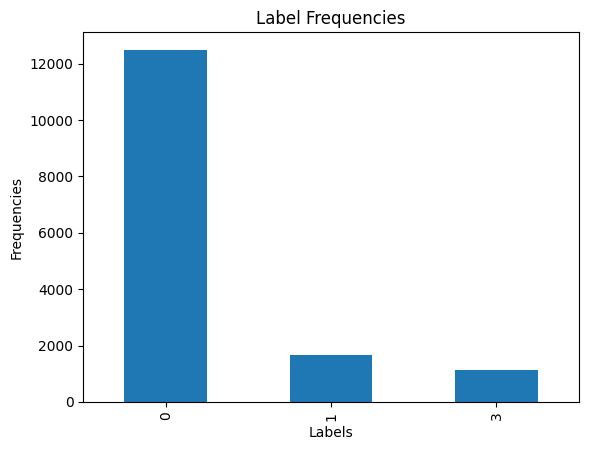

In [ ]:
# checking class distribution
y.value_counts()

y.value_counts().plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Frequencies')
plt.title('Label Frequencies')
plt.show()

**4.6 Statistics Summary**

Looking at the summary statistics: <br>
- Mean
- Standard deviation
- Max, Min etc.

In [22]:
X.describe()

,Label,Temperature_F,PIR_1,PIR_2,PIR_3,PIR_4,PIR_5,PIR_6,PIR_7,PIR_8,...,PIR_47,PIR_48,PIR_49,PIR_50,PIR_51,PIR_52,PIR_53,PIR_54,PIR_55,timestamp
count,15302.000000,15302.000000,1.530200e+04,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,...,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,1.530200e+04
mean,0.332767,80.383871,2.501256e+05,11013.891648,11517.838452,11578.490786,11269.104169,10795.036989,10312.208600,9907.840413,...,11559.512874,11541.448438,11439.599529,11283.987061,11103.084564,10919.279441,10743.028624,10585.803294,10449.395373,1.723205e+09
std,0.818451,22.860670,4.292858e+06,591.779937,656.662381,663.090247,605.916326,537.230304,501.390737,499.616070,...,627.975644,619.176515,598.543624,571.501348,546.292700,518.324545,487.192649,464.733099,450.216603,3.444757e+04
min,0.000000,0.000000,2.613000e+03,2615.000000,2614.000000,2611.000000,2612.000000,2613.000000,2616.000000,2614.000000,...,2606.000000,2606.000000,2605.000000,2605.000000,2609.000000,2605.000000,2604.000000,2603.000000,2602.000000,1.723145e+09
25%,0.000000,86.000000,1.033300e+04,10787.250000,11272.250000,11338.000000,11051.000000,10629.000000,10182.000000,9764.000000,...,11313.000000,11301.000000,11211.000000,11083.000000,10935.250000,10794.000000,10650.000000,10513.000000,10388.000000,1.723175e+09
50%,0.000000,86.000000,1.043100e+04,11002.000000,11557.000000,11629.000000,11301.000000,10790.000000,10311.000000,9910.000000,...,11583.000000,11566.000000,11471.000000,11319.000000,11137.000000,10948.000000,10760.000000,10597.000000,10454.000000,1.723205e+09
75%,0.000000,88.000000,1.056075e+04,11267.000000,11885.000000,11957.000000,11550.000000,10982.000000,10443.000000,10035.000000,...,11961.000000,11928.000000,11781.000000,11571.000000,11334.000000,11097.000000,10876.000000,10683.000000,10524.000000,1.723234e+09
max,3.000000,89.000000,1.116026e+08,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,...,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,1.723265e+09


**4.7 Looking for patterns in activity based on time of the day**

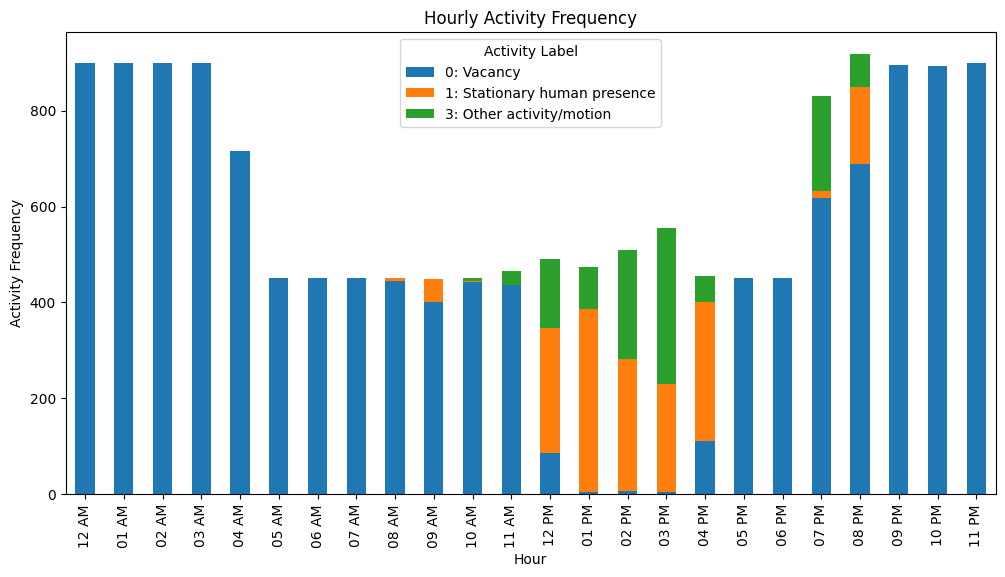

In [23]:
hourly_activity = y.groupby(pd.to_datetime(X['timestamp'],unit='s').dt.strftime('%I %p')).value_counts().unstack()

hourly_activity.index = pd.to_datetime(hourly_activity.index, format='%I %p')
hourly_activity = hourly_activity.sort_index()
hourly_activity.index = hourly_activity.index.strftime('%I %p')

hourly_activity.plot(kind='bar', stacked=True, figsize=(12,6))

plt.xlabel('Hour')
plt.ylabel('Activity Frequency')
plt.title('Hourly Activity Frequency')
plt.legend(
    title="Activity Label",
    labels=["0: Vacancy", "1: Stationary human presence", "3: Other activity/motion"]
)
plt.show()


**4.8 Variations in sensor readings based on time of the day**

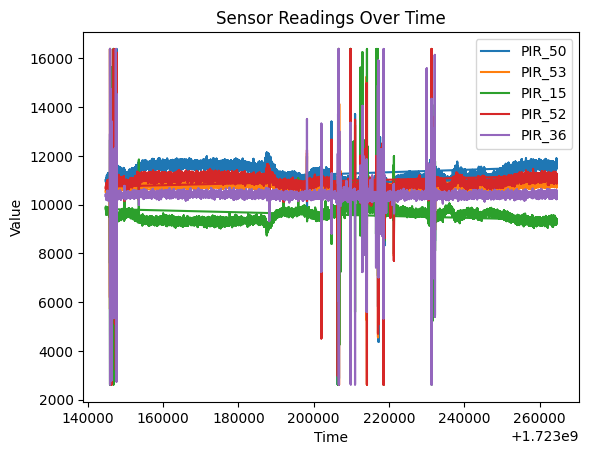

In [25]:
# Selecting only five random sensor readings column.
columns_starting_with_p = [col for col in X.columns if col.startswith('P')]
random_columns = np.random.choice(columns_starting_with_p, 5, replace=False)

time_points = X['timestamp']

for col in random_columns:
  plt.plot(time_points, X[col], label=col)

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Sensor Readings Over Time')
plt.legend()
plt.show()

**4.9 Maximum sensor readings over time**

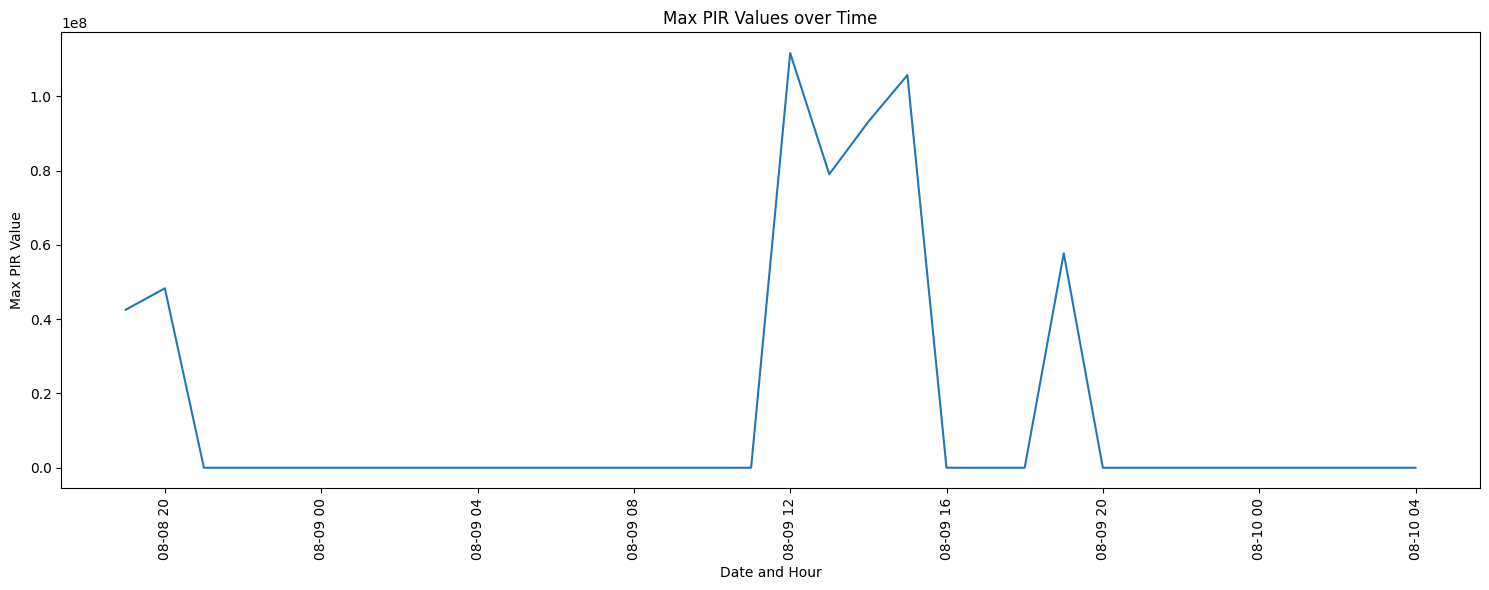

In [28]:
X['datetime'] = pd.to_datetime(X['timestamp'], unit='s')

# Group data by day and hour, and take the maximum PIR value for each hour
pir_data_grouped = X.groupby([X['datetime'].dt.date, X['datetime'].dt.hour])[[col for col in X.columns if col.startswith('P')]].max()


pir_data_grouped = pir_data_grouped.reset_index(names=['date', 'hour']) # name the index columns

# Create a single column with PIR values by taking max across all columns that start with 'P'
pir_data_grouped['max_PIR'] = pir_data_grouped[[col for col in pir_data_grouped.columns if col.startswith('P')]].max(axis=1)

pir_data_grouped['combined_datetime'] = pd.to_datetime(pir_data_grouped['date'].astype(str) + ' ' + pir_data_grouped['hour'].astype(str) + ':00:00')


# Plotting
plt.figure(figsize=(15, 6))
plt.plot(pir_data_grouped['combined_datetime'], pir_data_grouped['max_PIR'])

plt.xlabel('Date and Hour')
plt.ylabel('Max PIR Value')
plt.title('Max PIR Values over Time')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

X.drop(columns=['datetime'], inplace=True)

**4.10 Correlation Visualization**

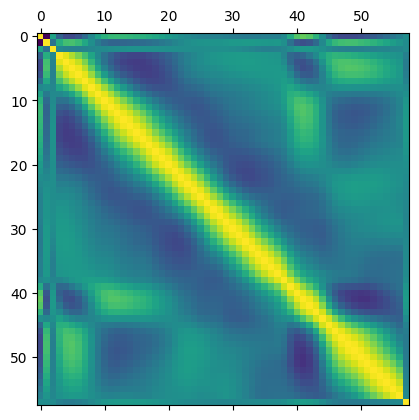

In [35]:
correlation_matrix = X.corr()
plt.matshow(correlation_matrix)
plt.show()

**4.11 Visualizing data using PCA**

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalized_dataframe = scaler.fit_transform(X)

number_of_components = 2
pca = PCA(n_components=number_of_components)

pca_cols = []
for i in range(number_of_components):
  pca_cols.append("pc"+str(i+1))

principalComponents = pca.fit_transform(normalized_dataframe)
principalDf = pd.DataFrame(data = principalComponents , columns = pca_cols)

finalDf = pd.concat([principalDf, y], axis = 1)
finalDf.head()

,pc1,pc2,Label
0,-0.109948,-0.479270,0
1,0.129897,-0.488331,1
2,-0.108723,-0.478216,0
3,-0.104748,-0.477114,0
4,-0.108664,-0.478311,0


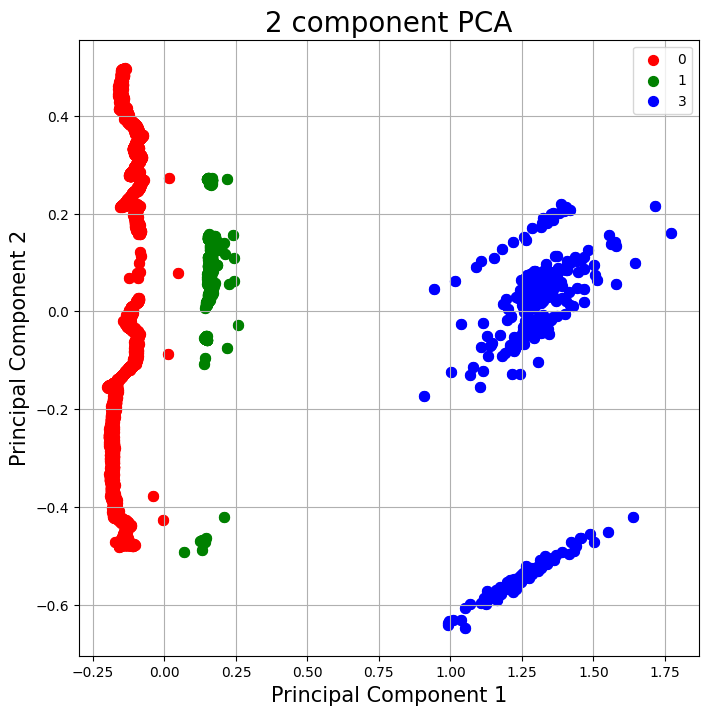

In [32]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)
targets = [0,1,3]
colors = ['r', 'g', 'b']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf['Label'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'pc1']
               , finalDf.loc[indicesToKeep, 'pc2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()

### **5. Preprocessing and Feature Engineering**

 **5.1 Add hour column to the dataframe**

In [10]:
data['datetime_str'] = data['Date'] + ' ' + data['Time']
data['datetime'] = pd.to_datetime(data['datetime_str'], format='%Y-%d-%m %H:%M:%S')
data['hour'] = data['datetime'].dt.hour

 **5.2 Drop unneccessary columns from dataframes**

In [11]:
data = data.drop(['Date', 'Time', 'datetime', 'datetime_str'], axis=1)

**5.3 Split to feature and target**

In [12]:
X = data.drop(['Label'], axis=1).values
y = data['Label'].values.astype(int)  # Ensure integer labels for multi-class classification
y = data['Label'].map(label_mapping).values.astype(int)

**5.4 Normalize the features**

In [13]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X = X.reshape((X.shape[0], 1, X.shape[1]))

**5.5 Create dataset for training and testing the model**

In [14]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

X_tensor = X_tensor.to(device)
y_tensor = y_tensor.to(device)

dataset = TensorDataset(X_tensor, y_tensor)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

### **6. Define & Train Model**

**6.1 Define LSTM Model**

In [2]:
class CustomLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, fc_layers=[32], num_classes=3):
        super(CustomLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        layers = []
        last_dim = hidden_dim
        for fc_dim in fc_layers:
            layers.append(nn.Linear(last_dim, fc_dim))
            layers.append(nn.ReLU())
            last_dim = fc_dim

        layers.append(nn.Linear(last_dim, num_classes))
        self.fc = nn.Sequential(*layers)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

**6.2 Define Training Loop**

In [16]:
def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loss, val_loss, test_loss = [], [], []
    train_acc, val_acc, test_acc = [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            preds_original = [inverse_label_mapping[p.item()] for p in preds]

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss.append(running_loss / len(train_loader))
        train_acc.append(correct / total)

        model.eval()
        with torch.no_grad():
            val_running_loss, val_correct, val_total = 0.0, 0, 0
            for x_val, y_val in val_loader:
                x_val, y_val = x_val.to(device), y_val.to(device)
                outputs = model(x_val)
                loss = criterion(outputs, y_val)
                val_running_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                preds_original = [inverse_label_mapping[p.item()] for p in preds]
                val_correct += (preds == y_val).sum().item()
                val_total += y_val.size(0)

            val_loss.append(val_running_loss / len(val_loader))
            val_acc.append(val_correct / val_total)

    return train_loss, val_loss, train_acc, val_acc

**6.3 Define common method for testing on data and output the following:**

**1. Macro F1-Score**<br>
**2. Class-wise Precision, Recall, F1**<br>
**3. Confusion Matrix**<br>

In [17]:
def test_and_show_metrics(model, data_loader, title=""):
    y_true = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print(f"{title} Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["0", "1", "3"]))

    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"{title} Macro F1-Score: {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=["0", "1", "3"], yticklabels=["0", "1", "3"])
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

**6.4 K-Fold Cross-Validation Loop**


****************************** Fold 1 ******************************

Fold-1 Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2009
           1       0.99      0.99      0.99       245
           3       1.00      0.99      1.00       195

    accuracy                           1.00      2449
   macro avg       1.00      0.99      1.00      2449
weighted avg       1.00      1.00      1.00      2449

Fold-1 Validation Macro F1-Score: 0.9952


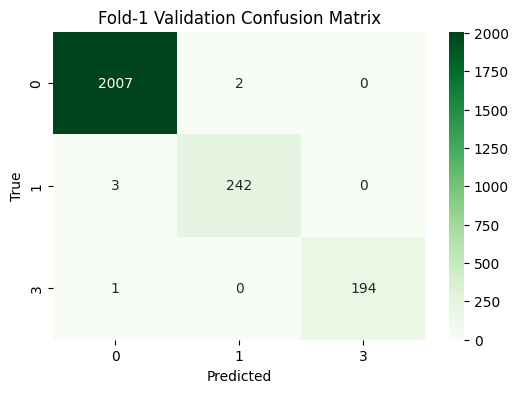

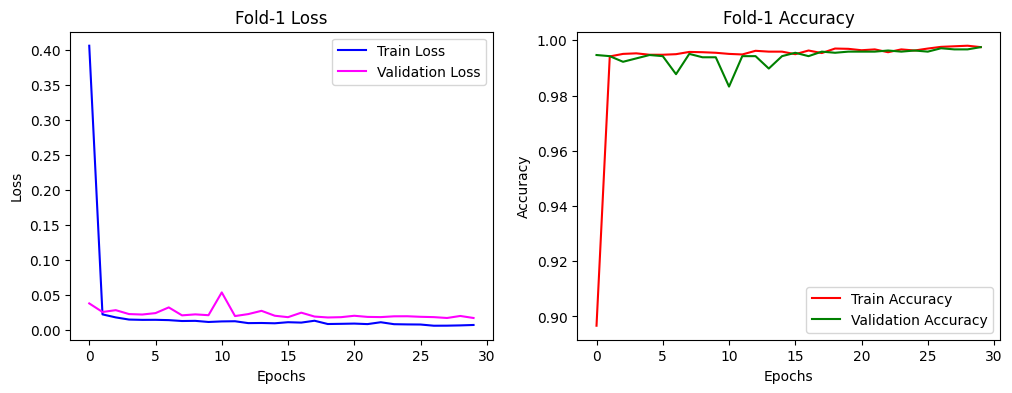

Final Metrics for fold 1
Final Train Loss: 0.0069, Validation Loss: 0.0169, Train Accuracy: 0.9975, Validation Accuracy: 0.9976

****************************** Fold 2 ******************************

Fold-2 Validation Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1993
           1       1.00      0.97      0.98       263
           3       1.00      0.99      0.99       192

    accuracy                           1.00      2448
   macro avg       1.00      0.98      0.99      2448
weighted avg       1.00      1.00      1.00      2448

Fold-2 Validation Macro F1-Score: 0.9908


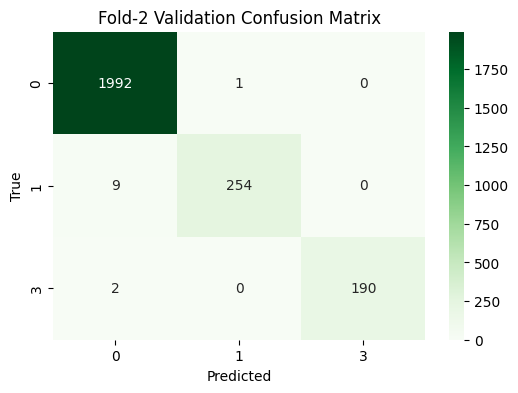

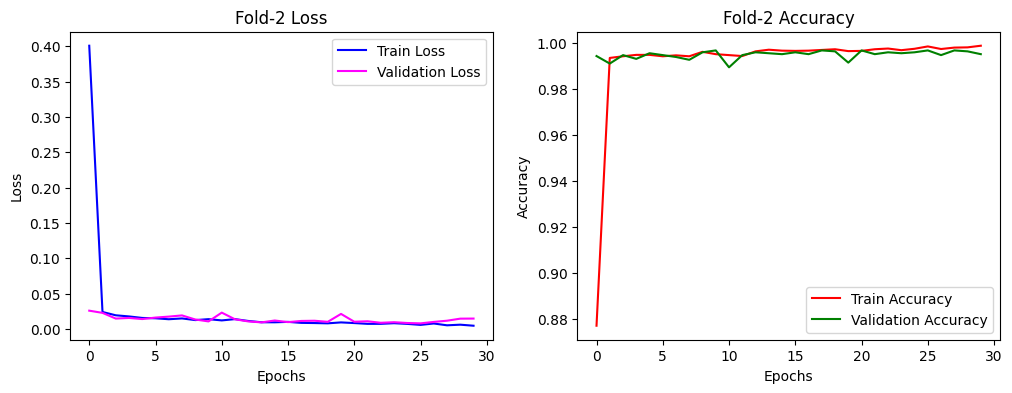

Final Metrics for fold 2
Final Train Loss: 0.0045, Validation Loss: 0.0146, Train Accuracy: 0.9988, Validation Accuracy: 0.9951

****************************** Fold 3 ******************************

Fold-3 Validation Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1993
           1       0.99      0.94      0.97       289
           3       1.00      1.00      1.00       166

    accuracy                           0.99      2448
   macro avg       0.99      0.98      0.99      2448
weighted avg       0.99      0.99      0.99      2448

Fold-3 Validation Macro F1-Score: 0.9879


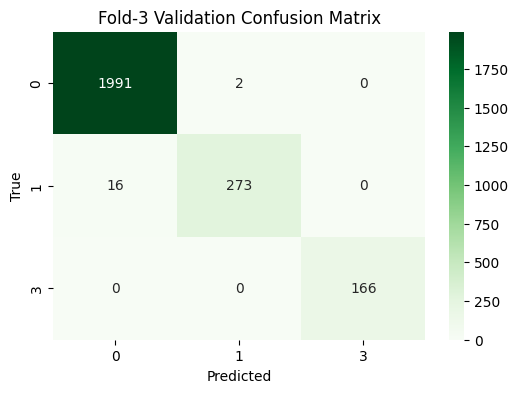

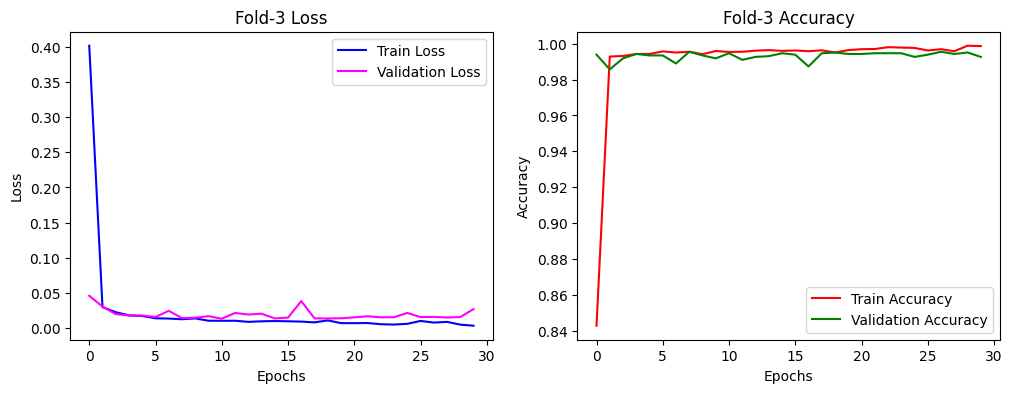

Final Metrics for fold 3
Final Train Loss: 0.0034, Validation Loss: 0.0271, Train Accuracy: 0.9987, Validation Accuracy: 0.9926

****************************** Fold 4 ******************************

Fold-4 Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2016
           1       0.96      1.00      0.98       248
           3       0.99      0.99      0.99       184

    accuracy                           1.00      2448
   macro avg       0.99      1.00      0.99      2448
weighted avg       1.00      1.00      1.00      2448

Fold-4 Validation Macro F1-Score: 0.9906


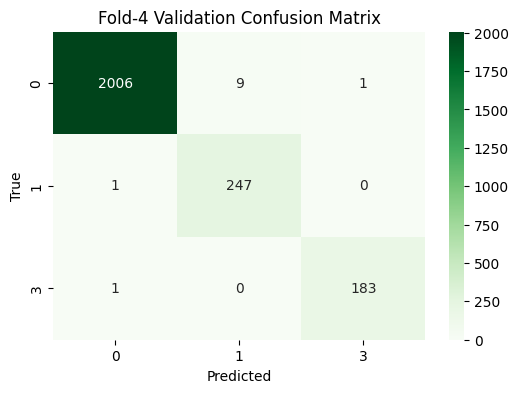

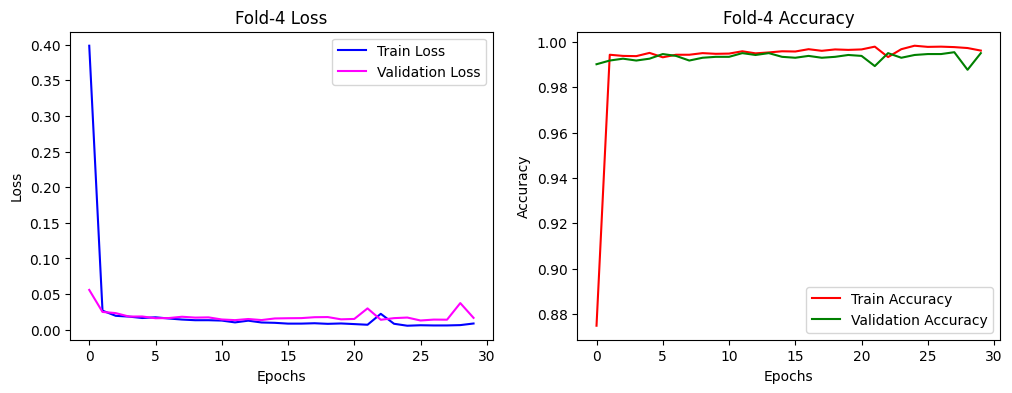

Final Metrics for fold 4
Final Train Loss: 0.0087, Validation Loss: 0.0166, Train Accuracy: 0.9962, Validation Accuracy: 0.9951

****************************** Fold 5 ******************************

Fold-5 Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2013
           1       0.99      0.98      0.98       256
           3       1.00      1.00      1.00       179

    accuracy                           1.00      2448
   macro avg       1.00      0.99      0.99      2448
weighted avg       1.00      1.00      1.00      2448

Fold-5 Validation Macro F1-Score: 0.9941


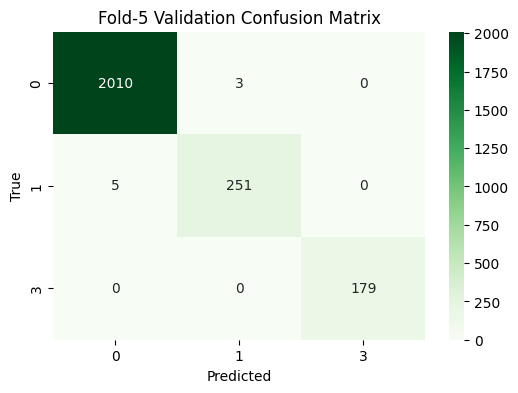

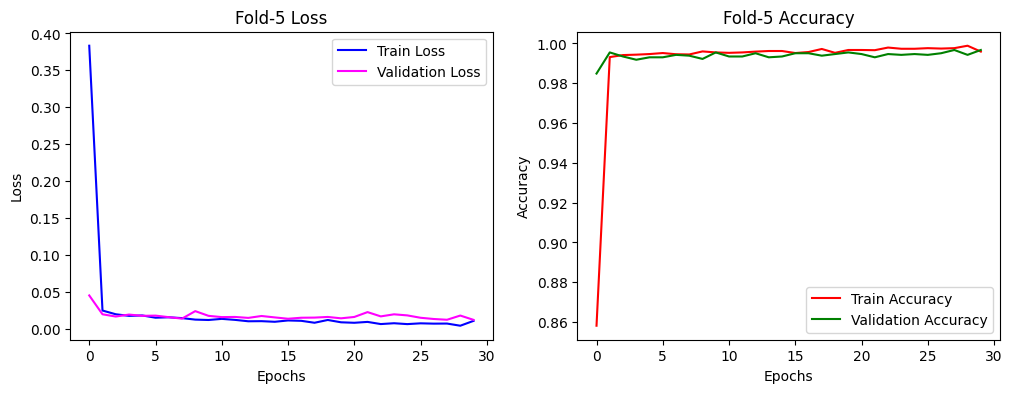

Final Metrics for fold 5
Final Train Loss: 0.0104, Validation Loss: 0.0118, Train Accuracy: 0.9959, Validation Accuracy: 0.9967


In [18]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []
train_accuracies = []
val_accuracies = []
test_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):
    print(f"\n****************************** Fold {fold + 1} ******************************\n")
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=64)

    model = CustomLSTM(input_dim=X.shape[2], fc_layers=[64, 32], num_classes=3)
    train_loss, val_loss, train_acc, val_acc = train_model(model, train_loader, val_loader)
    fold_results.append((train_loss, val_loss, train_acc, val_acc))
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Save the model
    torch.save(model.state_dict(), f"./saved_models/lstm_fold_{fold+1}.pth")

    # Show metrics
    test_and_show_metrics(model=model, data_loader=val_loader, title=f"Fold-{fold + 1} Validation")

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Train Loss', color='blue')
    plt.plot(val_loss, label='Validation Loss', color='magenta')
    plt.title(f'Fold-{fold + 1} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='Train Accuracy', color='red')
    plt.plot(val_acc, label='Validation Accuracy', color='green')
    plt.title(f'Fold-{fold + 1} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    plt.legend()
    plt.show()

    print(f"Final Metrics for fold {fold + 1}\nFinal Train Loss: {train_loss[-1]:.4f}, Validation Loss: {val_loss[-1]:.4f}, "
          f"Train Accuracy: {train_acc[-1]:.4f}, Validation Accuracy: {val_acc[-1]:.4f}")

**6.5 Mean Accuracy & Standard deviations across all K-folds.**

(Train Accuracy across all folds) Mean: 0.9974, Std Dev: 0.0012
(Validation Accuracy across all folds) Mean: 0.9954, Std Dev: 0.0017


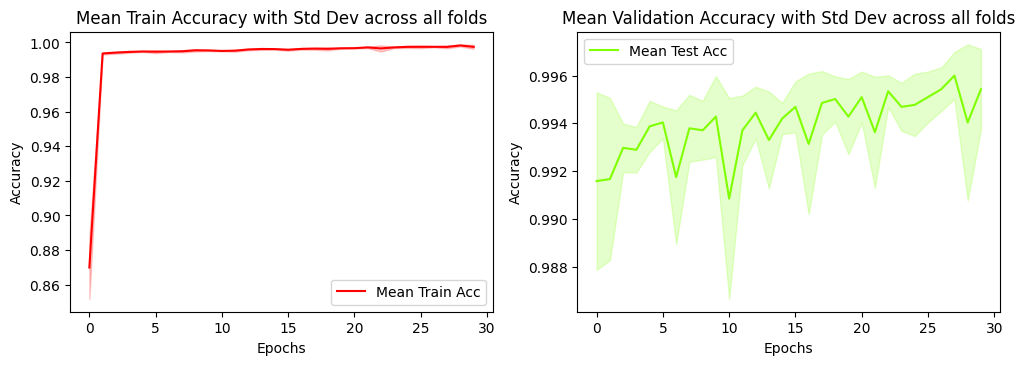

In [19]:
mean_train_accuracy = np.mean(train_accuracies, axis=0)
std_train_accuracy = np.std(train_accuracies, axis=0)

mean_val_accuracy = np.mean(val_accuracies, axis=0)
std_val_accuracy = np.std(val_accuracies, axis=0)

print(f"(Train Accuracy across all folds) Mean: {mean_train_accuracy[-1]:.4f}, Std Dev: {std_train_accuracy[-1]:.4f}")
print(f"(Validation Accuracy across all folds) Mean: {mean_val_accuracy[-1]:.4f}, Std Dev: {std_val_accuracy[-1]:.4f}")

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(mean_train_accuracy, label='Mean Train Acc', color='red')
plt.fill_between(range(len(mean_train_accuracy)), mean_train_accuracy - std_train_accuracy, mean_train_accuracy + std_train_accuracy, color='red', alpha=0.2)
plt.title('Mean Train Accuracy with Std Dev across all folds')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(mean_val_accuracy, label='Mean Test Acc', color='chartreuse')
plt.fill_between(range(len(mean_val_accuracy)), mean_val_accuracy - std_val_accuracy, mean_val_accuracy + std_val_accuracy, color='chartreuse', alpha=0.2)
plt.title('Mean Validation Accuracy with Std Dev across all folds')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### **7. Testing the Model**

Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2470
           1       0.99      0.99      0.99       365
           3       1.00      1.00      1.00       226

    accuracy                           1.00      3061
   macro avg       1.00      0.99      1.00      3061
weighted avg       1.00      1.00      1.00      3061

Test Macro F1-Score: 0.9953


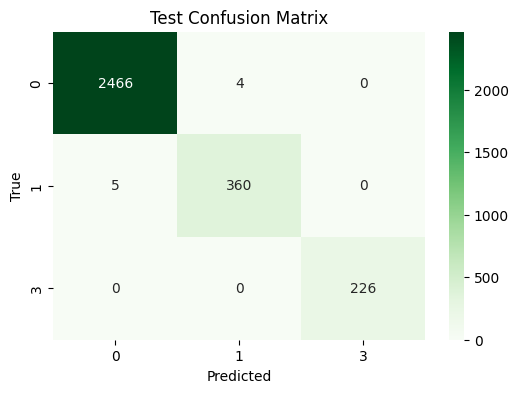

In [20]:
test_loader = DataLoader(test_dataset, batch_size=64)
test_and_show_metrics(model=model, data_loader=test_loader, title=f"Test")

### **8. Define Evaluate Model Method**

In [3]:
import torch
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

label_mapping = {0: 0, 1: 1, 3: 2}
inverse_label_mapping = {0: 0, 1: 1, 2: 3}

device = torch.device("mps" if torch.cuda.is_available() else "cpu")

def evaluate_model(datafile_location, checkpoint):
    df = pd.read_csv(datafile_location)
    df['datetime_str'] = df['Date'] + ' ' + df['Time']
    df['datetime'] = pd.to_datetime(df['datetime_str'], format='%Y-%d-%m %H:%M:%S')
    df['hour'] = df['datetime'].dt.hour

    df = df.drop(['Date', 'Time', 'datetime', 'datetime_str'], axis=1)

    X = df.drop(['Label'], axis=1).values
    y = df['Label'].values.astype(int) 
    y = df['Label'].map(label_mapping).values.astype(int)

    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    X = X.reshape((X.shape[0], 1, X.shape[1]))

    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y, dtype=torch.long).to(device)

    # eval_dataset = TensorDataset(X_tensor, y_tensor)

    model = CustomLSTM(input_dim=X.shape[2], fc_layers=[64, 32], num_classes=3)
    model.load_state_dict(torch.load(checkpoint))
    model.to(device)
    model.eval()

    with torch.no_grad():
        outputs = model(X_tensor)
        preds = torch.argmax(outputs, dim=1)
        accuracy = (preds == y_tensor).float().mean().item()

    return accuracy

### **9. Below is the example usage for Evaluate model method. Please run Cell-2, Cell-6.1 and Cell-8 before proceeding.**

In [4]:
evaluate_model('./pirvision_fog_presence_detection/pirvision_office_dataset1.csv', './saved_models/lstm_fold_1.pth')

0.9979087710380554